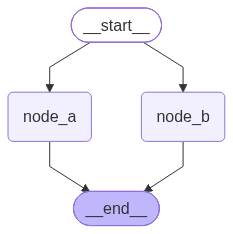

完整状态： {'__interrupt__': [Interrupt(value='请输入您的姓名', id='bfb80ed716ed5d810573f9cc3a4f1846'), Interrupt(value='请输入您的年龄', id='422238c5b719f082471cad257dca3dca')]}


In [3]:

from typing import TypedDict

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command

# ========== 1. 基础配置 ==========
load_dotenv(override=True)

# ========== 3. 大模型初始化 ==========
model = ChatOpenAI(
    model="deepseek-v4-flash",
    temperature=0.3,
    extra_body={
        "thinking": {"type": "disabled"}
    }
)

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) ->OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) ->OverAllState:
    age = interrupt("请输入您的年龄")
    return {
        "age": age
    }

# ========== 5. 构建工作流图 ==========
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
# 编译图，绑定检查点和长期存储

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

# 执行第一次图，触发中断
config = {
    "configurable": {
        "thread_id": "123"
    }
}

interrupt_res = graph.invoke({}, config=config)

print("完整状态：", interrupt_res)
# prompt = interrupt_res["__interrupt__"][0].value
# print("prompt：", prompt)
# username=input(prompt)
# resume_res = graph.invoke(Command(resume=username), config=config)
# print(resume_res)





In [5]:
# 恢复执行
resume_map = {}
for i in interrupt_res["__interrupt__"]:
    user_input = input(i.value)
    if "年龄" in i.value:
        resume_map[i.id] = int(user_input)
    else:
        resume_map[i.id] = user_input

resume_res = graph.invoke(Command(resume=resume_map),config=config)

print(resume_res)


KeyboardInterrupt: Interrupted by user